Intercept (B0): 7.0326
Slope (B1): 0.0475


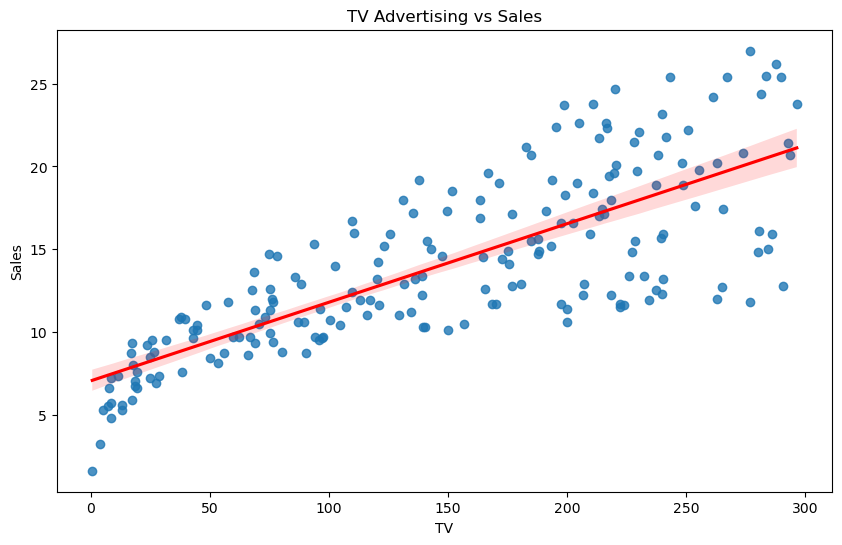

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load the dataset
df = pd.read_csv('Advertising.csv', index_col=0)

# Reshape data for Scikit-Learn
X = df[['TV']]
y = df['Sales']

# Fit the model
model = LinearRegression()
model.fit(X, y)

# Get coefficients
intercept = model.intercept_
slope = model.coef_[0]

print(f"Intercept (B0): {intercept:.4f}")
print(f"Slope (B1): {slope:.4f}")

# Visualization
plt.figure(figsize=(10, 6))
sns.regplot(x='TV', y='Sales', data=df, line_kws={"color": "red"})
plt.title('TV Advertising vs Sales')
plt.show()

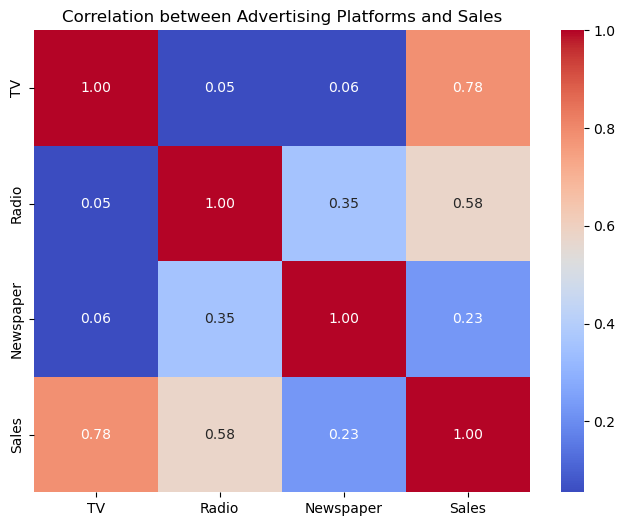

In [11]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between Advertising Platforms and Sales')
plt.show()

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load data - skipping the first unnamed index column
df = pd.read_csv('Advertising.csv', index_col=0)

# 1. Feature Selection (Predictors vs Target)
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# 2. Data Splitting (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Training
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Predictions and Evaluation
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"R-squared Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")

# Display Coefficients for Actionable Insights
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print("\nImpact of Each Platform on Sales:")
print(coefficients)

R-squared Score: 0.8994
Mean Squared Error: 3.1741

Impact of Each Platform on Sales:
           Coefficient
TV            0.044730
Radio         0.189195
Newspaper     0.002761
